In [225]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
import numpy as np
digits = load_digits()

In [226]:
X = digits.data.T      
y = digits.target   
print(X.shape)
print(y.shape)

(64, 1797)
(1797,)


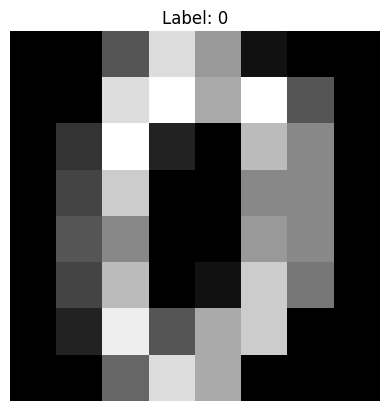

In [227]:
# viewing an image
plt.imshow(digits.images[0], cmap="gray")
plt.title(f"Label: {digits.target[0]}")
plt.axis("off")
plt.show()

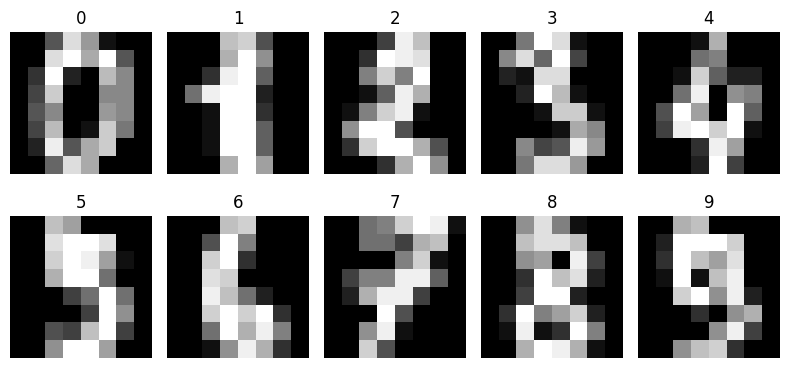

In [228]:
fig, axes = plt.subplots(2, 5, figsize=(8, 4))

for ax, image, label in zip(
        axes.ravel(),
        digits.images[:10],
        digits.target[:10]):
    
    ax.imshow(image, cmap="gray")
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [229]:
# each image in this dataset is 8 x 8 
# after flattening the shpae is (64,1)

# for hidden layer we use ReLu activation 
# for digit recognization we use softmax activation

In [230]:
# creating a layer class
class layer_dense:
    def __init__(self,n_inputs,n_neurons):
        self.weights = np.random.randn(n_neurons,n_inputs) * 0.01
        self.bias = np.zeros((n_neurons,1))
    def forward(self,x):
        self.x = x
        self.output = self.weights @ x + self.bias
        return self.output

In [231]:
# Relu activation
class Relu_activation:
    def forward(self,inputs):
        self.inputs = inputs
        self.output = np.maximum(0,inputs)
        return self.output

In [232]:
# softmax activation
class Softmax_activation:
    def forward(self,inputs):
        exp_values = np.exp(inputs - np.max(inputs, axis=0, keepdims=True))
        probabilites = exp_values / np.sum(exp_values, axis=0, keepdims=True)
        self.output = probabilites
        return self.output

In [233]:
relu_actv = Relu_activation()
softmax_actv = Softmax_activation()

In [234]:
# first creating a layer with 64 inputs and 5 neurons
layer_1 = layer_dense(64,32)
# taking outputs of the first layer and passing it to  Relu activation
output1 = relu_actv.forward(layer_1.forward(X))
# this output becomes the input of the next layer
layer_2 = layer_dense(32, 10)
output2 = layer_2.forward(output1)
predictions = softmax_actv.forward(output2)


In [235]:
y_pred = np.argmax(predictions, axis=0)
y_pred

array([6, 8, 4, ..., 4, 6, 7], shape=(1797,))

In [236]:
# backpropagation
# first we need to one hot encode the targets
Y = np.eye(10)[y].T
Y

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 1.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(10, 1797))

In [237]:
m = X.shape[1]
m

1797

In [238]:
dz2 = predictions - Y
dz2

array([[-0.8999746 ,  0.10104717,  0.09753228, ...,  0.09867051,
         0.10222756,  0.09857596],
       [ 0.09859531, -0.90198505,  0.09620832, ...,  0.09702404,
         0.09740236,  0.0958139 ],
       [ 0.0980558 ,  0.0962336 , -0.90203464, ...,  0.09837488,
         0.09561645,  0.09744872],
       ...,
       [ 0.1036794 ,  0.1010576 ,  0.1027131 , ...,  0.10215464,
         0.1045344 ,  0.10487814],
       [ 0.09735445,  0.10302735,  0.10276264, ..., -0.89729833,
         0.09874223, -0.89847588],
       [ 0.09804563,  0.10036979,  0.09847552, ...,  0.09950434,
        -0.90241607,  0.09819302]], shape=(10, 1797))

In [239]:
dW2 = (1/m) * (dz2 @ output1.T)
dW2

array([[ 1.85839418e-02, -5.32993716e-03,  2.96659961e-05,
         1.58687900e-02,  2.09772621e-03,  3.56880139e-03,
         4.60018088e-03,  2.57499564e-03, -7.24619940e-03,
         1.89175263e-02,  2.41233889e-02,  8.72246187e-03,
         1.89219247e-03,  6.50384792e-03, -3.38525376e-02,
         7.57529072e-05,  3.04239304e-02, -4.91067877e-02,
         1.22656561e-02,  1.32278976e-02, -4.50966787e-02,
         2.23916468e-04,  3.28526805e-02,  1.91551116e-02,
        -1.02762988e-02,  1.50840238e-03,  2.39079388e-03,
        -1.73666526e-02,  2.26415655e-02,  2.13607221e-02,
        -5.69150272e-02,  2.46873184e-02],
       [ 3.37233859e-03,  1.43921985e-03,  2.87911630e-05,
         3.17808689e-03,  3.11647133e-03,  1.69239285e-03,
         1.96763474e-03,  1.86082356e-03,  5.15037042e-03,
        -8.87331982e-03,  9.36198829e-03, -7.28265586e-03,
         6.47834794e-03, -5.02612014e-03,  1.22869138e-02,
         7.30694000e-05, -7.74831491e-03,  1.61859968e-02,
        -6.17

In [240]:
# bias gradient 
db2 = (1/m) * np.sum(dz2,axis=1,keepdims=True)
db2

array([[ 0.0005705 ],
       [-0.0034738 ],
       [-0.00184558],
       [-0.00367378],
       [ 0.0020598 ],
       [-0.00226372],
       [ 0.00182686],
       [ 0.00271113],
       [ 0.00432861],
       [-0.00024003]])

In [241]:
# backdrop through hidden layer
dA1 = layer_2.weights.T @ dz2
dA1

array([[ 0.00941283,  0.0001466 , -0.00247734, ..., -0.00416095,
        -0.0123945 , -0.00419616],
       [-0.00963544,  0.00718171, -0.01280181, ...,  0.00797817,
        -0.00271397,  0.00795563],
       [-0.00152255, -0.00060043, -0.01731086, ...,  0.0053049 ,
         0.00021156,  0.00529912],
       ...,
       [-0.0089606 ,  0.02811611, -0.0006171 , ..., -0.01059808,
         0.00337639, -0.01056467],
       [-0.00125668, -0.00361452,  0.01376684, ...,  0.00649637,
         0.00758066,  0.00659777],
       [ 0.00032123,  0.00179576, -0.00233967, ..., -0.00862837,
         0.00968308, -0.00861299]], shape=(32, 1797))

In [242]:
dz1 = dA1.copy()
dz1[relu_actv.inputs <= 0] = 0
dz1

array([[ 0.00941283,  0.0001466 , -0.00247734, ..., -0.00416095,
        -0.0123945 , -0.00419616],
       [-0.00963544,  0.00718171,  0.        , ...,  0.00797817,
        -0.00271397,  0.00795563],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.0089606 ,  0.02811611, -0.0006171 , ..., -0.01059808,
         0.00337639, -0.01056467],
       [-0.00125668, -0.00361452,  0.01376684, ...,  0.00649637,
         0.00758066,  0.00659777],
       [ 0.        ,  0.00179576, -0.00233967, ..., -0.00862837,
         0.00968308, -0.00861299]], shape=(32, 1797))

In [243]:
# gradients of W1 and b1
dW1 = (1/m) * dz1 @ X.T
dW1[0][:5]

array([0.        , 0.00021374, 0.002365  , 0.00067875, 0.00695998])

In [244]:
# for bias b1
db1 = (1/m) * np.sum(dz1,axis=1,keepdims=True)
db1

array([[ 2.75095135e-05],
       [-9.24026502e-04],
       [ 7.27617501e-05],
       [ 4.42586332e-04],
       [-8.18213693e-04],
       [-3.32826118e-04],
       [-1.78587980e-04],
       [ 6.30461968e-04],
       [-1.32856776e-04],
       [ 2.22842617e-03],
       [-3.07592810e-04],
       [ 8.61225005e-04],
       [-2.20169434e-04],
       [ 2.39164987e-05],
       [ 2.59658073e-04],
       [ 3.09225719e-05],
       [-5.80471529e-04],
       [ 5.89844257e-05],
       [ 4.25510111e-04],
       [-1.04948796e-03],
       [ 3.58011788e-04],
       [ 7.01801768e-05],
       [ 1.32324239e-04],
       [ 1.86471702e-04],
       [ 1.72959672e-05],
       [ 1.74081470e-04],
       [ 4.96217942e-04],
       [ 1.45294366e-03],
       [-1.94158112e-04],
       [ 4.26394866e-04],
       [ 1.43443656e-05],
       [-4.85460620e-04]])

In [245]:
# gradient descent 
learning_rate = 0.01

layer_1.weights -= learning_rate * dW1
layer_1.bias    -= learning_rate * db1

layer_2.weights -= learning_rate * dW2
layer_2.bias    -= learning_rate * db2

In [246]:
# categorical loss class
class Loss:
    def forward(self,y_pred,y_true):
        samples = y_pred.shape[1]
        correct_confidences = y_pred[y_true,np.arange(samples)]
        correct_confidences = np.clip(
            correct_confidences,
            1e-7,
            1 - 1e-7
        )
        losses = -np.log(correct_confidences)
        return np.mean(losses)


In [247]:
loss_function = Loss()
loss = loss_function.forward(predictions, y)
print(loss)

2.3011635321376613


In [248]:
from sklearn.model_selection import train_test_split

X = digits.data 
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X_train = X_train.T
X_test = X_test.T

In [249]:
X = X_train
y = y_train

Y = np.eye(10)[y].T

In [250]:
# final training loop
learning_rate = 0.005
epochs = 1000

accuracy_dict = {
    "accuracy": [],
    "w1": [],
    "w2": [],
    "b1": [],
    "b2": []
}

for epoch in range(epochs):

    #forward pass
    inputs = layer_1.forward(X)
    output1 = relu_actv.forward(inputs)
    output2 = layer_2.forward(output1)
    predictions = softmax_actv.forward(output2)

    #loss calculating
    loss = loss_function.forward(predictions,y)

    #accuracy
    predicted_class = np.argmax(predictions,axis=0)
    accuracy = np.mean(predicted_class==y)

    #backpropagation
    m = X.shape[1]
    dz2 = (predictions - Y)
    
    dW2 = (1/m) * (dz2 @ output1.T)
    db2 = (1/m) * np.sum(dz2,axis=1,keepdims=True)

    dA1 = layer_2.weights.T @ dz2

    dz1 = dA1.copy()
    dz1[relu_actv.inputs <= 0] = 0

    dW1 = (1/m) * (dz1 @ X.T)
    db1 = (1/m) * np.sum(dz1,axis=1,keepdims=True)

    #gradient descent
    layer_1.weights -= learning_rate * dW1
    layer_1.bias    -= learning_rate * db1

    layer_2.weights -= learning_rate * dW2
    layer_2.bias    -= learning_rate * db2

    if epoch % 100 == 0:
        print(
            f"Epoch: {epoch}, "
            f"Loss: {loss:.4f}, "
            f"Accuracy: {accuracy:.4f}"
        )
    accuracy_dict["accuracy"].append(accuracy)

    accuracy_dict["w1"].append(layer_1.weights.copy())
    accuracy_dict["w2"].append(layer_2.weights.copy())

    accuracy_dict["b1"].append(layer_1.bias.copy())
    accuracy_dict["b2"].append(layer_2.bias.copy())


Epoch: 0, Loss: 2.2996, Accuracy: 0.1211
Epoch: 100, Loss: 2.0301, Accuracy: 0.7154
Epoch: 200, Loss: 1.0621, Accuracy: 0.8399
Epoch: 300, Loss: 0.5525, Accuracy: 0.9047
Epoch: 400, Loss: 0.3678, Accuracy: 0.9248
Epoch: 500, Loss: 0.2791, Accuracy: 0.9374
Epoch: 600, Loss: 0.2279, Accuracy: 0.9478
Epoch: 700, Loss: 0.1949, Accuracy: 0.9555
Epoch: 800, Loss: 0.1717, Accuracy: 0.9638
Epoch: 900, Loss: 0.1544, Accuracy: 0.9666


In [251]:
best_index = np.argmax(accuracy_dict["accuracy"])

best_accuracy = accuracy_dict["accuracy"][best_index]

best_W1 = accuracy_dict["w1"][best_index]
best_W2 = accuracy_dict["w2"][best_index]

best_b1 = accuracy_dict["b1"][best_index]
best_b2 = accuracy_dict["b2"][best_index]

print("Best Accuracy:", best_accuracy)
print("Best Epoch:", best_index)

Best Accuracy: 0.9707724425887265
Best Epoch: 974


In [252]:
np.save("best_W1.npy", best_W1)
np.save("best_W2.npy", best_W2)

np.save("best_b1.npy", best_b1)
np.save("best_b2.npy", best_b2)

In [261]:
# creating a function to predict any handwritten digit
from PIL import Image

def predict_digit(image_path):
    
    img = Image.open(image_path)
    img = img.convert("L")

    img = np.array(img)

    img = 255 - img


    rows = np.any(img > 30, axis=1)
    cols = np.any(img > 30, axis=0)

    if not np.any(rows) or not np.any(cols):
        raise ValueError("No digit detected")

    ymin, ymax = np.where(rows)[0][[0, -1]]
    xmin, xmax = np.where(cols)[0][[0, -1]]

    img = img[ymin:ymax+1, xmin:xmax+1]

    img = Image.fromarray(img)
    img = img.resize((8, 8))
    img = np.array(img)

    img = img / 255.0
 
    x = img.reshape(64, 1)



    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(Image.open(image_path))
    plt.title("Original")
    
    plt.subplot(1,2,2)
    plt.imshow(img, cmap="gray")
    plt.title("Final 8x8")
    plt.show()

    W1 = np.load("best_W1.npy")
    b1 = np.load("best_b1.npy")

    W2 = np.load("best_W2.npy")
    b2 = np.load("best_b2.npy")

    z1 = W1 @ x + b1
    a1 = np.maximum(0, z1)

    z2 = W2 @ a1 + b2

    exp_values = np.exp(z2 - np.max(z2))
    probabilities = exp_values / np.sum(exp_values)

    predicted_digit = np.argmax(probabilities)
    confidence = np.max(probabilities)

    return predicted_digit, confidence

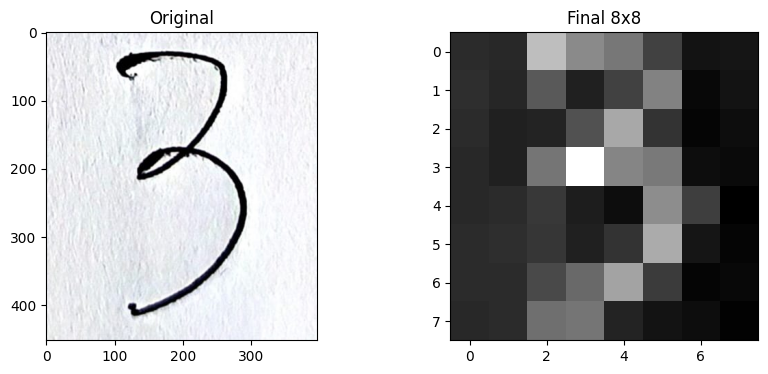

(np.int64(5), np.float64(0.10692423500476467))

In [262]:
# predicting a sample
path = "G:/neural_network_from_scratch/handwritten_digits/WhatsApp Image 2025-11-18 at 13.36.20(2).jpeg"
predict_digit(path)